<a href="https://colab.research.google.com/github/andie-dm/andie-dm/blob/main/Assignment_2_Andrea_Delgado_Preparing_Dataset_for_ML_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparing a Dataset for an ML Model

## Objective
Prepare a Gold Layer customer churn dataset by exploring the data, scaling numeric features, encoding categorical variables, engineering new features, validating the final table, and exporting it as a CSV file.

In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

In [23]:
df = pd.read_csv("/content/customer_churn_dataset-training-master - customer_churn_dataset-training-master.csv")

In [24]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [25]:
df.info()

#This tells me column names, data types, missing values
# object = text , int = interger , float = decimal

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [26]:
df.describe()

#gives me statistic info

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [27]:
df["Churn"].value_counts()

#Most clients stay

,count
Churn,
No,5174
Yes,1869


In [28]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(col)
    print(df[col].value_counts())
    print()

    #This answers which columns have text

customerID
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64

gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     3088
Yes                    2429
N

The dataset contains customer demographic information, subscription details, billing info and churn status. Numeric columns such as tenure, MonthlyCharges and TotalCharges may benefit from scaling because they have different set of values.
Several categorical variables, including gender, contract, internetService and PaymentMethod, require encoding before they can be used by a machine learning model. No major missing values were observed except that TotalCharges may require conversion to a numerical format.

In [29]:
scaler = StandardScaler()

df["tenure_standard"] = scaler.fit_transform(df[["tenure"]])

#fixing Scaling

In [30]:
robust = RobustScaler()

df["tenure_robust"] = robust.fit_transform(df[["tenure"]])

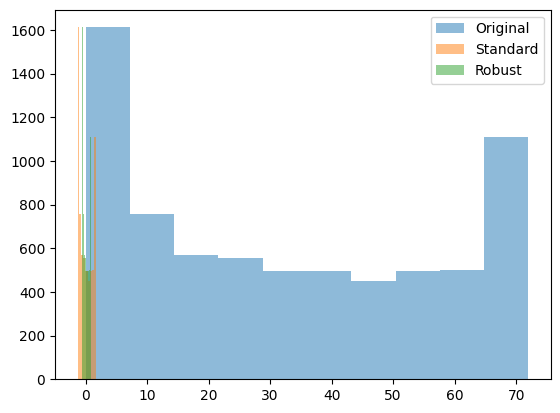

In [31]:
plt.hist(df["tenure"], alpha=.5)

plt.hist(df["tenure_standard"], alpha=.5)

plt.hist(df["tenure_robust"], alpha=.5)

plt.legend(["Original","Standard","Robust"])

StandardScaler produced a well-centered distribution, while RobustScaler reduced the influence of extreme values. Because tenure contains a few customers with unusually long subscriptions, RobustScaler better preserved the overall distribution.

In [32]:
pd.get_dummies(df["gender"])

,Female,Male
0,True,False
1,False,True
2,False,True
3,False,True
4,True,False
...,...,...
7038,False,True
7039,True,False
7040,True,False
7041,False,True


In [33]:
encoder = OrdinalEncoder(
    categories=[[
        "Month-to-month",
        "One year",
        "Two year"
    ]]
)

df["Contract_encoded"] = encoder.fit_transform(df[["Contract"]])

#Original Encoding contract, monthly = 0, one year = 1, two year = 2

One-hot encoding was used for gender because Male and Female have no natural order. Ordinal encoding was used for Contract because the categories represent increasing levels of customer commitment.

In [34]:
df["tenure_years"] = df["tenure"] / 12

In [35]:
df["spend_per_month"] = df["TotalCharges"] / df["tenure"].replace(0,np.nan)

#This tell me how much each customer spend each month

tenure_years makes customer longevity easier to interpret because years are more intuitive than months.

spend_per_month normalizes customer spending by accounting for how long they have been subscribed, making comparisons between customers more meaningful.

In [36]:
df.isna().sum()

#checkin missing values

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [37]:
df.drop_duplicates(inplace=True)

#Checking for duplicates

In [38]:
print(df.shape)

(7043, 26)


In [39]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,tenure_standard,tenure_robust,Contract_encoded,tenure_years,spend_per_month
count,7043.000000,7043.000000,7043.000000,7032.000000,7.043000e+03,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441,-2.421273e-17,0.073286,0.690473,2.697596,64.799424
std,0.368612,24.559481,30.090047,2266.771362,1.000071e+00,0.533902,0.833755,2.046623,30.185891
min,0.000000,0.000000,18.250000,18.800000,-1.318165e+00,-0.630435,0.000000,0.000000,13.775000
25%,0.000000,9.000000,35.500000,401.450000,-9.516817e-01,-0.434783,0.000000,0.750000,36.179891
50%,0.000000,29.000000,70.350000,1397.475000,-1.372744e-01,0.000000,0.000000,2.416667,70.373239
75%,0.000000,55.000000,89.850000,3794.737500,9.214551e-01,0.565217,1.000000,4.583333,90.179560
max,1.000000,72.000000,118.750000,8684.800000,1.613701e+00,0.934783,2.000000,6.000000,121.400000


In [40]:
df.to_csv("customer_churn_gold.csv", index=False)

In [41]:
from google.colab import files

files.download("customer_churn_gold.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Reloading and Reprocessing Data

To resolve the `NameError` and `FileNotFoundError`, we need to re-execute the steps that load and prepare the `df` DataFrame. This ensures that `df` is correctly defined and all transformations are applied before saving the 'gold layer' dataset.

In [42]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, RobustScaler, OrdinalEncoder

# List files in the /content directory to verify the exact file name
!ls -l /content/

# Reload the DataFrame from the original source
df = pd.read_csv("/content/customer_churn_dataset-training-master - customer_churn_dataset-training-master.csv")

# Convert TotalCharges to numeric, coercing errors to NaN
# Although df.info() showed float64, it's good practice to ensure numeric type and handle potential non-numeric entries if any were present.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Handle missing values by dropping rows where TotalCharges is NaN
# As identified in df.isna().sum(), there are 11 missing values in TotalCharges and spend_per_month.
df.dropna(subset=['TotalCharges'], inplace=True)

# Re-apply transformations

# Scaling 'tenure'
scaler = StandardScaler()
df["tenure_standard"] = scaler.fit_transform(df[["tenure"]])

robust = RobustScaler()
df["tenure_robust"] = robust.fit_transform(df[["tenure"]])

# Encoding 'Contract'
encoder = OrdinalEncoder(
    categories=[[
        "Month-to-month",
        "One year",
        "Two year"
    ]]
)
df["Contract_encoded"] = encoder.fit_transform(df[["Contract"]])

# Feature Engineering
df["tenure_years"] = df["tenure"] / 12

# Recreate spend_per_month after handling TotalCharges NaNs and before dropping any further NaNs
df["spend_per_month"] = df["TotalCharges"] / df["tenure"].replace(0,np.nan)

# Drop any remaining NaNs in spend_per_month that might arise if tenure was 0 after TotalCharges handling
df.dropna(subset=['spend_per_month'], inplace=True)

# Display the head of the processed DataFrame
display(df.head())

# Display info to confirm data types and non-null counts after reprocessing
display(df.info())

total 2404
-rw-r--r-- 1 root root  977488 Aug  3 21:20 'customer_churn_dataset-training-master - customer_churn_dataset-training-master.csv'
-rw-r--r-- 1 root root 1478163 Aug  3 21:21  customer_churn_gold.csv
drwxr-xr-x 1 root root    4096 Jun  4 13:32  sample_data


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_standard,tenure_robust,Contract_encoded,tenure_years,spend_per_month
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Yes,Electronic check,29.85,29.85,No,-1.280248,-0.608696,0.0,0.083333,29.850000
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,Mailed check,56.95,1889.50,No,0.064303,0.108696,1.0,2.833333,55.573529
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Yes,Mailed check,53.85,108.15,Yes,-1.239504,-0.586957,0.0,0.166667,54.075000
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,Bank transfer (automatic),42.30,1840.75,No,0.512486,0.347826,1.0,3.750000,40.905556
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Yes,Electronic check,70.70,151.65,Yes,-1.239504,-0.586957,0.0,0.166667,75.825000


<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

None

In [43]:
# Save the processed DataFrame to a CSV file
df.to_csv("customer_churn_gold.csv", index=False)
print("DataFrame successfully saved to customer_churn_gold.csv")

DataFrame successfully saved to customer_churn_gold.csv


In [44]:
# Download the generated CSV file
from google.colab import files

files.download("customer_churn_gold.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
import os

print(os.listdir("/content"))

['.config', 'customer_churn_gold.csv', 'customer_churn_dataset-training-master - customer_churn_dataset-training-master.csv', 'sample_data']


In [46]:
df_.head(10)

NameError: name 'df_' is not defined

In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
import pandas as pd

filename = next(iter(uploaded))
df = pd.read_csv(filename)

print("Loaded file:", filename)
print("Dataset shape:", df.shape)
df.head(10)